# Домашнее задание к семинару 12 (HW12)

Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

Выполнил: [Ваше имя]

## 1. Импорты, seed и среда

In [14]:
# Базовые библиотеки
import os
import random
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Настройки графиков
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

Device: cuda


## 2. Данные и первичный анализ

Если файл `S12-hw-dataset.csv` отсутствует, генерируем синтетические данные.
Затем загружаем их, проверяем, сортируем по дате, визуализируем.

Загружен файл S12-hw-dataset.csv
Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64


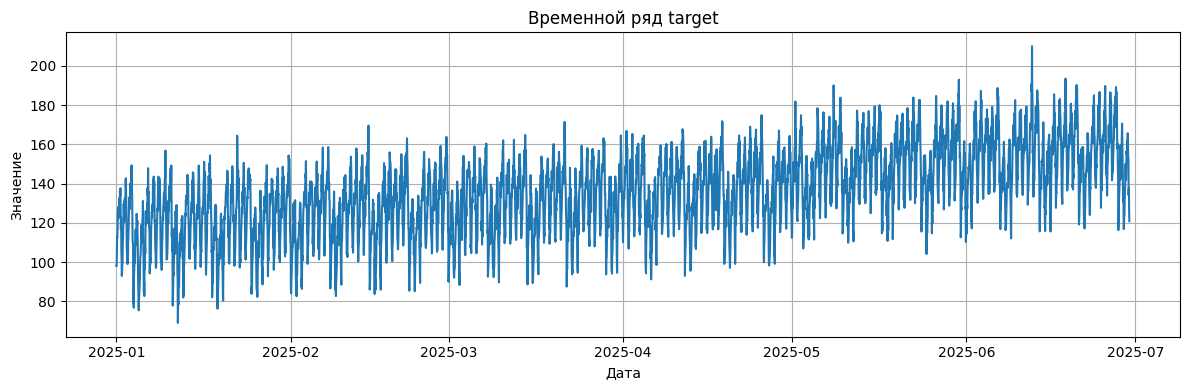

In [15]:
# Проверка наличия файла
csv_file = 'S12-hw-dataset.csv'

df = pd.read_csv(csv_file)
print(f'Загружен файл {csv_file}')

# Преобразуем дату
df['date'] = pd.to_datetime(df['date'])
# Сортируем по дате
df = df.sort_values('date').reset_index(drop=True)

# Первичный анализ
print('Размер датасета:', df.shape)
print('Диапазон дат:', df['date'].min(), '-', df['date'].max())
print('Пропуски по колонкам:')
print(df.isnull().sum())

# График ряда
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'], lw=1.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.tight_layout()
plt.savefig('artifacts/figures/series_overview.png') 
plt.show()

## 3. Корректный temporal split

Разобьем данные на train/validation/test хронологически.
Доли: 70% train, 15% val, 15% test.

train: 2025-01-01 00:00:00 – 2025-05-06 23:00:00 | 3024 строк
val:   2025-05-07 00:00:00 – 2025-06-02 23:00:00 | 648 строк
test:  2025-06-03 00:00:00 – 2025-06-29 23:00:00 | 648 строк


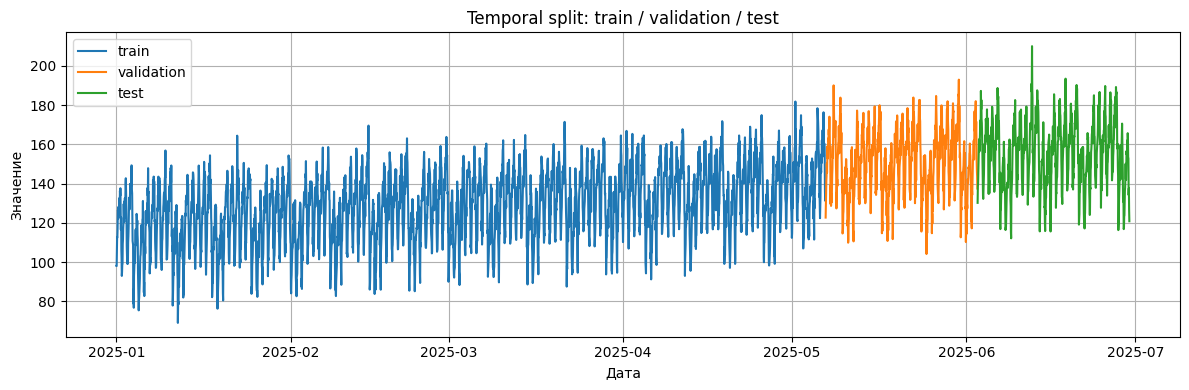

In [16]:
# **Почему random split некорректен?**

# Random split перемешивает наблюдения, нарушая временную упорядоченность. 
# Модель будет учиться на данных из будущего и тестироваться на прошлом, что не соответствует реальному сценарию прогнозирования. 
# Временной split сохраняет хронологию: тренируемся на прошлом, проверяем на будущем.

train_frac = 0.7
val_frac = 0.15
test_frac = 0.15
n = len(df)
train_end = int(n * train_frac)
val_end = int(n * (train_frac + val_frac))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f'train: {train_df["date"].min()} – {train_df["date"].max()} | {len(train_df)} строк')
print(f'val:   {val_df["date"].min()} – {val_df["date"].max()} | {len(val_df)} строк')
print(f'test:  {test_df["date"].min()} – {test_df["date"].max()} | {len(test_df)} строк')

# Визуализация split
plt.figure(figsize=(12, 4))
plt.plot(train_df['date'], train_df['target'], label='train', lw=1.5)
plt.plot(val_df['date'], val_df['target'], label='validation', lw=1.5)
plt.plot(test_df['date'], test_df['target'], label='test', lw=1.5)
plt.title('Temporal split: train / validation / test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

**Почему random split некорректен?**

Random split перемешивает наблюдения, нарушая временную упорядоченность. Модель будет учиться на данных из будущего и тестироваться на прошлом, что не соответствует реальному сценарию прогнозирования. Временной split сохраняет хронологию: тренируемся на прошлом, проверяем на будущем.

## 4. Признаки для baseline-моделей

Построим лаговые (`lag_1`, `lag_7`, `lag_14`), скользящие средние и стандартные отклонения (`rolling_mean_7`, `rolling_std_7`), а также календарные признаки (день недели). Все вычисления проводим на обучающей части с последующим преобразованием валидационной и тестовой частей (shift и rolling берутся из прошлого).

In [17]:
def add_features(df, target_col='target'):
    df = df.copy()
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)

    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()

    df['dayofweek'] = df['date'].dt.dayofweek

    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    return df

train_feat = add_features(train_df).dropna().reset_index(drop=True)
val_feat   = add_features(val_df).dropna().reset_index(drop=True)
test_feat  = add_features(test_df).dropna().reset_index(drop=True)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dow_sin', 'dow_cos']
target_col = 'target'

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]
X_val   = val_feat[feature_cols]
y_val   = val_feat[target_col]
X_test  = test_feat[feature_cols]
y_test  = test_feat[target_col]

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}')
print(f'X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}')

X_train shape: (3010, 7), y_train shape: (3010,)
X_val shape:   (634, 7), y_val shape:   (634,)
X_test shape:  (634, 7), y_test shape:  (634,)


## 5. Baseline-модели

### B1: Naive (последнее известное значение)
### B2: Moving average
### B3: Ridge на признаках из раздела 4

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

# B1: Naive
naive_pred_val = val_feat['lag_1'].values
res_naive_val = evaluate(y_val, naive_pred_val, 'B1')

# B2: Moving average (7)
# baseline B2 (moving-average)
ma7_pred_val = val_feat['rolling_mean_7'].values
res_ma7_val = evaluate(y_val, ma7_pred_val, 'B2')

# B3: Ridge на признаках
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred_val = ridge.predict(X_val_scaled)
res_ridge_val = evaluate(y_val, ridge_pred_val, 'B3')

# Собираем результаты в DataFrame
results_val = pd.DataFrame([res_naive_val, res_ma7_val, res_ridge_val])

print('Результаты на валидации:')
print(results_val.to_string(index=False))

Результаты на валидации:
model       MAE      RMSE     MAPE
   B1  6.461262  8.241294 4.408359
   B2 12.731875 15.272014 8.839994
   B3  7.307524  8.859561 4.874027


## 6. Подготовка оконных последовательностей для GRU

Для прогнозирования следующего значения будем использовать окно `window_size` предыдущих наблюдений. Создадим `Dataset` и `DataLoader`. Используем только тренировочные данные для построения последовательностей и масштабирования.

In [19]:
window_size = 30
batch_size = 32

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size, scaler=None):
        self.series = series
        self.window = window_size
        if scaler is None:
            self.scaler = StandardScaler()
            self.scaler.fit(series.reshape(-1, 1))
        else:
            self.scaler = scaler
        scaled = self.scaler.transform(series.reshape(-1, 1)).flatten()
        self.X, self.y = [], []
        for i in range(len(scaled) - window_size):
            self.X.append(scaled[i:i+window_size])
            self.y.append(scaled[i+window_size])
        self.X = np.array(self.X).reshape(-1, window_size, 1).astype(np.float32)
        self.y = np.array(self.y).astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

train_series = train_df[target_col].values
val_series = val_df[target_col].values
test_series = test_df[target_col].values

train_dataset = TimeSeriesDataset(train_series, window_size)
val_dataset = TimeSeriesDataset(val_series, window_size, scaler=train_dataset.scaler)
test_dataset = TimeSeriesDataset(test_series, window_size, scaler=train_dataset.scaler)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Размеры обучающих последовательностей:', len(train_dataset))
print('Размеры валидационных последовательностей:', len(val_dataset))
print('Размеры тестовых последовательностей:', len(test_dataset))

Размеры обучающих последовательностей: 2994
Размеры валидационных последовательностей: 618
Размеры тестовых последовательностей: 618


## 7. Модель GRU

Определим простую однослойную GRU с линейным слоем для прогноза следующего значения.

In [20]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=48, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1]   # (batch, hidden_size)
        out = self.fc(last_hidden)  # (batch, 1)
        return out.squeeze(-1)

model = GRUForecaster().to(device)
print(model)

GRUForecaster(
  (gru): GRU(1, 48, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=48, out_features=1, bias=True)
)


c:\Users\Karl\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


## 8. Функции обучения и оценки

In [21]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50
best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train_loss: {train_loss:.5f} | val_loss: {val_loss:.5f}')

print(f'Лучшее val_loss: {best_val_loss:.5f}')

Epoch  10 | train_loss: 0.10279 | val_loss: 0.13192
Epoch  20 | train_loss: 0.09500 | val_loss: 0.12726
Epoch  30 | train_loss: 0.09257 | val_loss: 0.12745
Epoch  40 | train_loss: 0.09082 | val_loss: 0.12693
Epoch  50 | train_loss: 0.08910 | val_loss: 0.12639
Лучшее val_loss: 0.12636


In [22]:
model.load_state_dict(best_model_state)
model.eval()

GRUForecaster(
  (gru): GRU(1, 48, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=48, out_features=1, bias=True)
)

## 9. Оценка лучшей модели на тестовой выборке

In [23]:
def get_predictions(model, dataset, scaler):
    model.eval()
    preds_scaled = []
    trues_scaled = []
    with torch.no_grad():
        for xb, yb in DataLoader(dataset, batch_size=batch_size, shuffle=False):
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds_scaled.extend(pred)
            trues_scaled.extend(yb.numpy())
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    trues = scaler.inverse_transform(np.array(trues_scaled).reshape(-1, 1)).flatten()
    return trues, preds

y_true_val, y_pred_val = get_predictions(model, val_dataset, train_dataset.scaler)

res_gru_val = evaluate(y_true_val, y_pred_val, 'R1')

results_val = pd.concat([results_val, pd.DataFrame([res_gru_val])], ignore_index=True)

print('Результаты на валидации:')
print(results_val.to_string(index=False))

Результаты на валидации:
model       MAE      RMSE     MAPE
   B1  6.461262  8.241294 4.408359
   B2 12.731875 15.272014 8.839994
   B3  7.307524  8.859561 4.874027
   R1  5.054813  6.570416 3.427713


## 10. Сравнение и выбор лучшей модели

Выберем лучшую модель по наименьшей MAE на валидации.

In [24]:
# Выбираем лучшую модель по MAE на валидации
best_val_mae_idx = results_val['MAE'].idxmin()
best_model_name_val = results_val.loc[best_val_mae_idx, 'model']
best_mae_val = results_val.loc[best_val_mae_idx, 'MAE']
print(f'Лучшая модель на валидации: {best_model_name_val} с MAE = {best_mae_val:.4f}')
print(f"{best_model_name_val}")
if best_model_name_val == 'B1':
    final_pred_test = test_feat['lag_1'].values
elif best_model_name_val == 'B2':
    final_pred_test = test_feat['rolling_mean_7'].values
elif best_model_name_val == 'B3':
    X_test_scaled = scaler.transform(test_feat[feature_cols])
    final_pred_test = ridge.predict(X_test_scaled)
elif best_model_name_val == 'R1':
    y_true_test, y_pred_test = get_predictions(model, test_dataset, train_dataset.scaler)
    final_pred_test = y_pred_test
else:
    raise ValueError('Неизвестная модель')

if best_model_name_val !="R1":
    final_metrics = evaluate(y_test, final_pred_test, best_model_name_val)
    final_test_mae = final_metrics['MAE']
    final_test_rmse = final_metrics['RMSE']
    final_test_mape = final_metrics['MAPE']
else:
    final_metrics = evaluate(y_true_test, final_pred_test, best_model_name_val)
    final_test_mae = final_metrics['MAE']
    final_test_rmse = final_metrics['RMSE']
    final_test_mape = final_metrics['MAPE']

print(f'Её результаты на тесте: MAE = {final_test_mae:.4f}, RMSE = {final_test_rmse:.4f}, MAPE = {final_test_mape:.2f}%')

Лучшая модель на валидации: R1 с MAE = 5.0548
R1
Её результаты на тесте: MAE = 5.7264, RMSE = 7.3281, MAPE = 3.74%


## 11. Сохранение артефактов

Сохраним все необходимые файлы: runs.csv, best_gru.pt, best_gru_config.json, графики.

runs.csv сохранён
best_gru.pt и best_gru_config.json сохранены


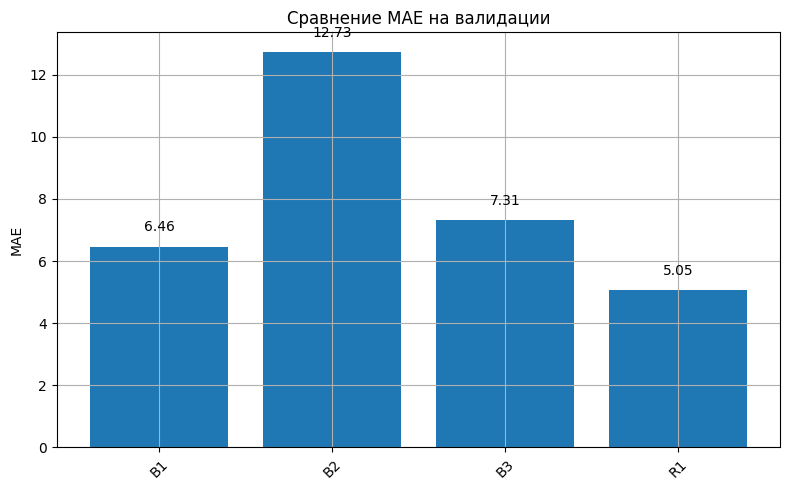

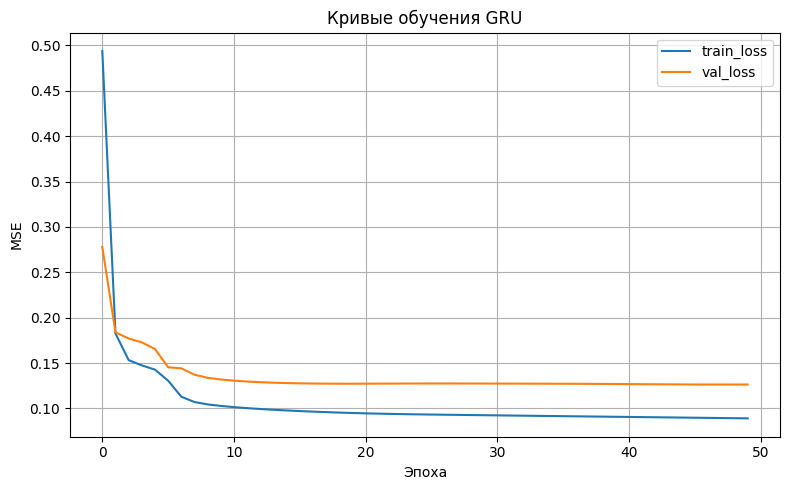

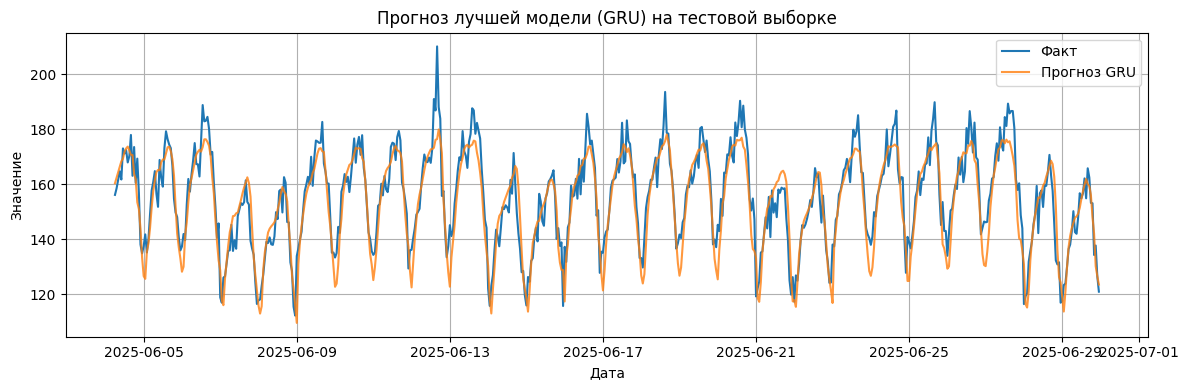

In [25]:

os.makedirs('artifacts/figures', exist_ok=True)

runs = []
for exp in [['B1',"B1 (naive)"], ['B2',"B2 (moving_avg)"], ['B3',"B3 (ridge)"], ['R1',"GRU(hidden=48,layers=2,dropout=0.2)"]]:
    val_row = results_val[results_val['model'] == exp[0]].iloc[0]
    runs.append({
        'experiment_id': exp[0],
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'train:70%, val:15%, test:15%',
        'window_size': window_size if exp[0] == 'R1' else None,
        'horizon': 1,
        'model_summary': exp[1],
        'features_summary': 'lag1,lag7,lag14,rolling7,dayofweek' if exp[0] != 'R1' else 'window30',
        'scaler': 'StandardScaler' if exp[0] == 'B3' else ('MinMaxScaler' if exp[0] == 'R1' else None),
        'optimizer': 'Adam' if exp[0] == 'R1' else None,
        'lr': 1e-3 if exp[0] == 'R1' else None,
        'epochs_trained': num_epochs if exp[0] == 'R1' else None,
        'best_val_mae': val_row['MAE'],
        'best_val_rmse': val_row['RMSE'],
        'best_val_mape': val_row['MAPE'],
        'test_mae': None if exp[0] !="R1" else final_test_mae,
        'test_rmse': None if exp[0] !="R1" else final_test_rmse,
        'test_mape': None if exp[0] !="R1" else final_test_mape,
        'notes': ''
    })
runs_df = pd.DataFrame(runs)
runs_df.to_csv('artifacts/runs.csv', index=False)
print('runs.csv сохранён')
 
torch.save(best_model_state, 'artifacts/best_gru.pt')
config = {
    'input_size': 1,
    'hidden_size': 32,
    'num_layers': 1,
    'window_size': window_size,
    'batch_size': batch_size,
    'learning_rate': 1e-3,
    'seed': 42,
    'scaler_mean': train_dataset.scaler.mean_.tolist()[0] if hasattr(train_dataset.scaler, 'mean_') else None,
    'scaler_scale': train_dataset.scaler.scale_.tolist()[0] if hasattr(train_dataset.scaler, 'scale_') else None
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('best_gru.pt и best_gru_config.json сохранены')

plt.figure(figsize=(8, 5))
bars = plt.bar(results_val['model'], results_val['MAE'])
plt.title('Сравнение MAE на валидации')
plt.ylabel('MAE')
for bar, val in zip(bars, results_val['MAE']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}', ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Кривые обучения GRU')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

plt.figure(figsize=(12, 4))
test_dates = test_df['date'].iloc[window_size:].reset_index(drop=True)
plt.plot(test_dates, y_true_test, label='Факт', lw=1.5)
plt.plot(test_dates, y_pred_test, label='Прогноз GRU', lw=1.5, alpha=0.8)
plt.title('Прогноз лучшей модели (GRU) на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()